review questions

In [18]:
# 2.77
import numpy as np
import scipy.linalg as la

A = np.array([[4, 2], [2, 2]])
la.cholesky(A)

array([[2., 1.],
       [0., 1.]])

exercises

In [19]:
# 2.5
A = np.array([[1, 0, 0], [1, -1, 0], [1, -2, 1]])
la.inv(A)

array([[ 1.,  0.,  0.],
       [ 1., -1.,  0.],
       [ 1., -2.,  1.]])

In [20]:
# 2.11
def forward_substitution(L, b):
    n = L.shape[0]
    y = np.zeros_like(b)
    for i in range(n):
        y[i] = (b[i] - np.dot(L[i, :i], y[:i])) / L[i, i]
    return y

In [21]:
# 2.17
A = np.array([[1, -1, 0], [-1, 2, -1], [0, -1, 1]])
la.lu(A)

(array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]),
 array([[ 1.,  0.,  0.],
        [-1.,  1.,  0.],
        [ 0., -1.,  1.]]),
 array([[ 1., -1.,  0.],
        [ 0.,  1., -1.],
        [ 0.,  0.,  0.]]))

In [22]:
# 2.18
A = np.array([[0, 1], [1, 0]])
la.lu(A)

(array([[0., 1.],
        [1., 0.]]),
 array([[1., 0.],
        [0., 1.]]),
 array([[1., 0.],
        [0., 1.]]))

computer problems

In [23]:
A = np.array([[.1, .2, .3], [.4, .5, .6], [.7, .8, .9]])
np.linalg.cond(A)
la.solve(A, [.1, .3, .5])

np.finfo(np.float64).nmant
np.log10(1 << 52)

c:\Users\chuny\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.02982e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


np.float64(15.653559774527022)

In [24]:
# 2.2
# (a)
A = np.array([
    [2, 4, -2],
    [4, 9, -3],
    [-2, -1, 7],
])

b = np.array([2, 8, 10])

la.solve(A, b) # array([-7.00000000e+00,  4.00000000e+00, -3.88578059e-16])
P, L, U =la.lu(A)
y = la.solve_triangular(L, P.T @ b, lower=True)
la.solve_triangular(U, y) # array([-7.,  4.,  0.])

# (b)
c = [4, 8, -6]
la.solve(A, c) # array([-1.,  1., -1.])
y = la.solve_triangular(L, P.T @ c, lower=True)
la.solve_triangular(U, y) # array([-1.,  1., -1.])

# (c)
A_tilde = A.copy()
A_tilde[0, 1] = 2
A_tilde
la.solve(A_tilde, b) # array([3.        , 0.33333333, 2.33333333])


def solve_after_lu(b, P, L, U):
    y = la.solve_triangular(L, P.T @ b, lower=True)
    return la.solve_triangular(U, y)


v = np.eye(3)[1]
u = np.eye(3)[0] * 2

y = solve_after_lu(b, P, L, U)
z = solve_after_lu(u, P, L, U)

y + z / (1 - v @ z)  * (v @ y) # array([3.        , 0.33333333, 2.33333333])


array([3.        , 0.33333333, 2.33333333])

In [25]:
# 2.3
a = 1 / np.sqrt(2)
A = np.zeros((13, 13))
b = np.zeros(13)

A[0, 1], A[0, 5] = 1, -1
A[1, 2], b[1] = 1, 10
A[2, 0], A[2, 3], A[2, 4] = a, -1, -a
A[3, 0], A[3, 2], A[3, 4] = a, 1, a
A[4, 3], A[4, 7] = 1, -1
A[5, 6], b[5] = 1, 0
A[6, 4], A[6, 5], A[6, 8], A[6, 9] = a, 1, -a, -1
A[7, 4], A[7, 6], A[7, 8], b[7] = a, 1, a, 15
A[8, 9], A[8, 12] = 1, -1
A[9, 10], b[9] = 1, 20
A[10, 7], A[10, 8], A[10, 11] = 1, a, -a
A[11, 8], A[11, 10], A[11, 11] = a, 1, a
A[12, 11], A[12, 12] = a, 1

x1 = la.solve(A, b)
'''
array([-28.28427125,  20.        ,  10.        , -30.        ,
14.14213562,  20.        ,   0.        , -30.        ,
         7.07106781,  25.        ,  20.        , -35.35533906,
        25.        ])
'''
print(np.array2string(A, precision=2, max_line_width=100))


def full_to_banded(A, l, u):
    """将普通矩阵 A 转换为 solve_banded 所需的 ab 格式"""
    # 创建一个全零的 ab 矩阵，形状为 (l+u+1, A.shape[0])
    ab = np.zeros((l + u + 1, A.shape[0]))
    # 填充主对角线
    ab[u, :] = np.diag(A)
    for k in range(1, u + 1):
        ab[u - k, k:] = np.diag(A, k)
    for k in range(1, l + 1):
        ab[u + k, :-k] = np.diag(A, -k)
    return ab


A_banded = full_to_banded(A, l=3, u=5)
x2 = la.solve_banded((3, 5), A_banded, b)
print(np.allclose(x1, x2)) # True

import scipy.sparse as sp
import scipy.sparse.linalg as spla
A_sparse = sp.csr_matrix(A)
x3 = spla.spsolve(A_sparse, b)
print(np.allclose(x1, x3)) # True

[[ 0.    1.    0.    0.    0.   -1.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    1.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.71  0.    0.   -1.   -0.71  0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.71  0.    1.    0.    0.71  0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    1.    0.    0.    0.   -1.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    1.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.71  1.    0.    0.   -0.71 -1.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.71  0.    1.    0.    0.71  0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.    1.    0.    0.   -1.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    1.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    1.    0.71  0.    0.   -0.71  0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.71  0.    1.    0.71  0.  ]
 [ 0.    0.    0.    0.    0

In [26]:
# 2.4
A1 = np.array([
    [10, -7, 0],
    [-3, 2, 6],
    [5, -1, 5],
])

A2 = np.array([
    [-73, 78, 24],
    [92, 66, 25],
    [-80, 37, 10],
])

# using inverse and compare with software cond
P1, L1, U1 = la.lu(A1)
A1_inverse = solve_after_lu(np.eye(3), P1, L1, U1)
print(np.allclose(A1_inverse, la.inv(A1)))
cond1_software = np.linalg.cond(A1, p=1)
cond1 = la.norm(A1, ord=1) * la.norm(A1_inverse, ord=1)
print(f"cond1: {cond1}, cond1_software: {cond1_software}")

P2, L2, U2 = la.lu(A2)
A2_inverse = solve_after_lu(np.eye(3), P2, L2, U2)
cond2_software = np.linalg.cond(A2, p=1)
cond2 = la.norm(A2, ord=1) * la.norm(A2_inverse, ord=1)
print(f"cond2: {cond2}, cond2_software: {cond2_software}")


# (a)
def inverse_norm_y(P, L, U):
    n = U.shape[0]
    y = np.zeros(n)
    for i in range(n):
        prev_sum = np.dot(U.T[i, :i], y[:i])
        b = np.sign(prev_sum)
        if np.sign(prev_sum) == 0:
            b = 1

        y[i] = (-b - prev_sum) / U[i, i]
    
    return P @ la.solve_triangular(L.T, y)


def estimate_inverse_norm(P, L, U):
    y = inverse_norm_y(P, L, U)
    x = solve_after_lu(y, P, L, U)
    return la.norm(x, ord=1) / la.norm(y, ord=1)


cond1_estimate = la.norm(A1, ord=1) * estimate_inverse_norm(P1, L1, U1)
print(f"a cond1_estimate: {cond1_estimate}, cond1_software: {cond1_software}")

cond2_estimate = la.norm(A2, ord=1) * estimate_inverse_norm(P2, L2, U2)
print(f"a cond2_estimate: {cond2_estimate}, cond2_software: {cond2_software}")


# (b)
def estimate_inverse_norm_random(P, L, U):
    n = U.shape[0]
    estimates = []
    for _ in range(5):
        y = np.random.randn(n)
        x = solve_after_lu(y, P, L, U)
        estimates.append(la.norm(x, ord=1) / la.norm(y, ord=1))
    return np.max(estimates)


cond1_estimate_random = la.norm(A1, ord=1) * estimate_inverse_norm_random(P1, L1, U1)
print(f"b cond1_estimate_random: {cond1_estimate_random}, cond1_software: {cond1_software}")

cond2_estimate_random = la.norm(A2, ord=1) * estimate_inverse_norm_random(P2, L2, U2)
print(f"b cond2_estimate_random: {cond2_estimate_random}, cond2_software: {cond2_software}")

True
cond1: 12.774193548387096, cond1_software: 12.774193548387096
cond2: 4016285.0002640393, cond2_software: 4016285.0002640393
a cond1_estimate: 11.20707596253902, cond1_software: 12.774193548387096
a cond2_estimate: 3205083.9490105566, cond2_software: 4016285.0002640393
b cond1_estimate_random: 10.380379008155582, cond1_software: 12.774193548387096
b cond2_estimate_random: 3624281.0241026594, cond2_software: 4016285.0002640393


In [27]:
# 2.5
A = np.array([
    [21, 67, 88, 73],
    [76, 63, 7, 20],
    [0, 85, 56, 54],
    [19.3, 43, 30.2, 29.4], 
], dtype=np.float32)

b = np.array([141, 109, 218, 93.7], dtype=np.float32)
P, L, U = la.lu(A)
x = solve_after_lu(b, P, L, U)
z = np.ones_like(x)
print(x)

while la.norm(z, ord=1) != 0:
    r = b.astype(np.float64) - A @ x.astype(np.float64)
    r = r.astype(np.float32) # aarray([ 2.5808811e-05, -4.7683716e-06, -1.6689301e-06,  4.4642638e-06], dtype=float32)
    z = solve_after_lu(r, P, L, U)
    x += z

print(x)
print(b.astype(np.float64) - A @ x.astype(np.float64))

[-0.9999941  2.000028  -2.9999037  3.9998562]
[-1.  2. -3.  4.]
[0. 0. 0. 0.]


In [28]:
#  2.6
def hilbert_matrix(n):
    """生成 n x n 的 Hilbert 矩阵"""
    return np.array([[1/(i+j-1) for j in range(1, n+1)] for i in range(1, n+1)])


for n in range(1, 14):
    H = hilbert_matrix(n)
    x = np.ones(n)
    b = H @ x
    x_computed = la.solve(H, b)
    r = b - H @ x_computed
    error = la.norm(x_computed - x, ord=np.inf)
    print(f"n={n}, error={error}, residual={la.norm(r, ord=np.inf)}")



# [np.log10(np.linalg.cond(hilbert_matrix(n), p=np.inf)) for n in range(1, 15)]

n=1, error=0.0, residual=0.0
n=2, error=6.661338147750939e-16, residual=0.0
n=3, error=8.215650382226158e-15, residual=0.0
n=4, error=3.97237798210881e-13, residual=1.1102230246251565e-16
n=5, error=2.723510306168464e-11, residual=2.220446049250313e-16
n=6, error=6.118270334809495e-10, residual=1.1102230246251565e-16
n=7, error=2.4040033963501628e-08, residual=4.440892098500626e-16
n=8, error=2.2108053021607788e-07, residual=4.440892098500626e-16
n=9, error=1.0716895696649686e-05, residual=2.220446049250313e-16
n=10, error=0.0006500474001995826, residual=2.220446049250313e-16
n=11, error=0.010863043081975277, residual=2.220446049250313e-16
n=12, error=0.4324585940221368, residual=1.1102230246251565e-16
n=13, error=17.628723444547962, residual=4.440892098500626e-16


c:\Users\chuny\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.4694e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\chuny\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.64082e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [29]:
# 2.7
def generate_matrix(n):
    M = np.tril(np.ones((n, n)) * -1, -1)
    np.fill_diagonal(M, 1)
    M[:, -1] = 1
    return M

print(generate_matrix(5))

# (a) max element in U is 2 ** (n-1)
# (b)

for n in range(1, 40):
    A = generate_matrix(n)
    x_true = np.ones(n) + np.arange(n) * 0.1
    b = A @ x_true
    x = la.solve(A, b)
    # print(x_true)
    # print(x)
    error = la.norm(x - x_true, ord=np.inf)
    cond = np.linalg.cond(A, p=np.inf)
    r = la.norm(b - A @ x, ord=np.inf)
    print(f"n={n}, error={error}, cond={cond}, r={r}")


[[ 1.  0.  0.  0.  1.]
 [-1.  1.  0.  0.  1.]
 [-1. -1.  1.  0.  1.]
 [-1. -1. -1.  1.  1.]
 [-1. -1. -1. -1.  1.]]
n=1, error=0.0, cond=1.0, r=0.0
n=2, error=0.0, cond=2.0, r=0.0
n=3, error=2.220446049250313e-16, cond=3.0, r=4.440892098500626e-16
n=4, error=2.220446049250313e-16, cond=4.0, r=4.440892098500626e-16
n=5, error=1.1102230246251565e-15, cond=5.0, r=1.7763568394002505e-15
n=6, error=1.3322676295501878e-15, cond=6.0, r=3.552713678800501e-15
n=7, error=2.220446049250313e-15, cond=7.0, r=3.552713678800501e-15
n=8, error=5.773159728050814e-15, cond=8.0, r=8.881784197001252e-15
n=9, error=1.687538997430238e-14, cond=9.0, r=3.019806626980426e-14
n=10, error=1.1546319456101628e-14, cond=10.0, r=3.730349362740526e-14
n=11, error=2.2648549702353193e-14, cond=11.0, r=7.638334409421077e-14
n=12, error=9.103828801926284e-14, cond=12.0, r=2.575717417130363e-13
n=13, error=3.637090628672013e-13, cond=13.0, r=6.217248937900877e-13
n=14, error=7.274181257344026e-13, cond=14.0, r=1.350031197

In [30]:
# 2.8 by deepseek
import numpy as np

# 设置随机种子保证可重复
np.random.seed(2025)

n = 20   # 矩阵大小

# 生成一个条件数约为 1e8 的矩阵 A
Q, _ = np.linalg.qr(np.random.randn(n, n))
s = np.logspace(0, -20, n)   # 奇异值从 1 到 1e-8
A = Q.T @ np.diag(s) @ Q

# 已知解
x_true = np.ones(n)
b = A @ x_true

# 定义不同的缩放对角矩阵
scalings = {
    "No scaling": np.eye(n),
    "Mild (0.5-2)": np.diag(np.random.uniform(0.5, 2, n)),
    "Moderate (1e-2 to 1e1)": np.diag(10 ** np.random.uniform(-2, 1, n)),
    "Extreme (1e-8 to 1e2)": np.diag(10 ** np.random.uniform(-8, 2, n)),
    "Row scaling (1/row_norm)": np.diag(1.0 / np.linalg.norm(A, axis=1))
}

# 存储结果
results = {}

for name, D in scalings.items():
    DA = D @ A
    Db = D @ b
    
    # 条件数
    cond = np.linalg.cond(DA)
    
    # 求解
    x = np.linalg.solve(DA, Db)
    
    # 误差和残差
    err_rel = np.linalg.norm(x - x_true) / np.linalg.norm(x_true)
    resid = Db - DA @ x
    resid_rel = np.linalg.norm(resid) / np.linalg.norm(Db)
    
    results[name] = {
        "cond(DA)": cond,
        "relative error": err_rel,
        "relative residual": resid_rel
    }

# 打印结果
print(f"{'Scaling':<25} {'cond(DA)':>12} {'rel error':>12} {'rel residual':>12}")
for name, stats in results.items():
    print(f"{name:<25} {stats['cond(DA)']:12.2e} {stats['relative error']:12.2e} {stats['relative residual']:12.2e}")

Scaling                       cond(DA)    rel error rel residual
No scaling                    8.46e+17     9.19e-01     5.30e-16
Mild (0.5-2)                  2.01e+17     1.18e+00     4.71e-16
Moderate (1e-2 to 1e1)        1.71e+19     5.39e-01     1.17e-16
Extreme (1e-8 to 1e2)         9.42e+23     1.72e+01     9.17e-16
Row scaling (1/row_norm)      2.16e+17     1.13e+00     4.43e-16


In [31]:
# 2.11
np.random.seed(0)
def random_spd_matrix(n):
    M = np.random.randn(n, n)          # 随机矩阵（可能非对称）
    A = M.T @ M                        # 对称半正定
    # 添加一个小对角项确保数值正定（若 M 可能不满秩）
    A += 0.1 * np.eye(n)
    return A


def lu_no_pivot(A):
    n = len(A)
    A = A.astype(float).copy()
    for i in range(n):
        for j in range(i+1, n):
            A[j, i] /= A[i, i]
            A[j, i+1:] -= A[j, i] * A[i, i+1:]
    
    return np.tril(A, k=-1) + np.eye(n), np.triu(A)


A = hilbert_matrix(5)
print(np.linalg.cond(A))
L, U = lu_no_pivot(A)
print(np.allclose(A, L @ U))


def lu_partial_pivot(A):
    """
    对矩阵 A 进行带部分主元的 LU 分解 (PA = LU)
    
    参数:
        A: n x n 矩阵 (numpy array)
    
    返回:
        P: n x n 置换矩阵 (numpy array)
        L: n x n 单位下三角矩阵
        U: n x n 上三角矩阵
    """
    n = len(A)
    # 拷贝矩阵，避免修改原矩阵
    U = A.astype(float).copy()
    L = np.eye(n)
    P = np.eye(n)
    
    for i in range(n):
        # 部分主元：在列 i 中，从行 i 向下寻找绝对值最大的行
        max_row = np.argmax(np.abs(U[i:, i])) + i
        if max_row != i:
            # 交换 U 的第 i 行和第 max_row 行
            U[[i, max_row]] = U[[max_row, i]]
            # 交换 L 的第 i 行和第 max_row 行（注意只交换前 i-1 列已经消去的部分）
            L[[i, max_row], :i] = L[[max_row, i], :i]
            # 交换 P 的行（累积置换）
            P[[i, max_row]] = P[[max_row, i]]

        # 如果主元为零（奇异矩阵），停止分解
        if abs(U[i, i]) < 1e-15:
            raise ValueError("矩阵奇异，无法进行 LU 分解")

        # 消去下方元素
        for j in range(i+1, n):
            factor = U[j, i] / U[i, i]
            L[j, i] = factor
            U[j, i:] -= factor * U[i, i:]
    
    return P, L, U


def lu_complete_pivot(A):
    """
    完全主元 LU 分解: P A Q = L U
    返回 P, L, U, Q 矩阵
    """
    A = A.astype(float).copy()
    n = A.shape[0]
    P = np.eye(n)       # 行置换
    Q = np.eye(n)       # 列置换
    L = np.eye(n)

    for k in range(n):
        # 在子矩阵 A[k:n, k:n] 中寻找最大元
        sub = A[k:, k:]
        r, c = np.unravel_index(np.argmax(np.abs(sub)), sub.shape)
        r += k
        c += k

        if abs(A[r, c]) < 1e-15:
            raise ValueError("矩阵奇异，无法分解")

        # 交换行
        if r != k:
            A[[k, r]] = A[[r, k]]
            P[[k, r]] = P[[r, k]]
            L[[k, r], :k] = L[[r, k], :k]   # 交换 L 已填充部分

        # 交换列
        if c != k:
            A[:, [k, c]] = A[:, [c, k]]
            Q[:, [k, c]] = Q[:, [c, k]]
            # 注意：U 尚未完全构造，但列交换会影响后续消元，已通过交换 A 实现


        # 消元
        for i in range(k+1, n):
            factor = A[i, k] / A[k, k]
            L[i, k] = factor
            A[i, k:] -= factor * A[k, k:]

    # 最后 U 取 A 的上三角部分
    U = np.triu(A)
    return P, Q, L, U


A = np.random.rand(10, 10)
P, L, U = lu_partial_pivot(A)
np.allclose(P @ A, L @ U)

P, Q, L, U = lu_complete_pivot(A)
np.allclose(P @ A @ Q, L @ U)


476607.25024100044
True


True

In [32]:
# 2.12
def lu_triangular(A):
    n = len(A)

    a = np.zeros(n)
    a[1:] = np.diag(A, -1)

    b = np.diag(A)

    c = np.zeros(n)
    c[:n-1] = np.diag(A, 1)

    d = np.zeros(n)
    m = np.zeros(n)
    d[0] = A[0, 0]
    for i in range(1, n):
        m[i] = a[i] / d[i-1]
        d[i] = b[i] - m[i] * c[i-1]

    L = np.eye(n) + np.diag(m[1:], -1)
    U = np.diag(d) + np.diag(c[:-1], 1)
    return L, U


n = 5  # 矩阵大小

# 随机生成三条对角线
main_diag = np.random.rand(n)          # 主对角线 (n 个)
upper_diag = np.random.rand(n-1)       # 上对角线 (n-1 个)
lower_diag = np.random.rand(n-1)       # 下对角线 (n-1 个)

# 构造三对角矩阵
A = np.diag(main_diag) \
    + np.diag(upper_diag, k=1) \
    + np.diag(lower_diag, k=-1)

print(A) 
L, U = lu_triangular(A)
np.allclose(A, L @ U)


[[0.67781654 0.57615733 0.         0.         0.        ]
 [0.95274901 0.27000797 0.59204193 0.         0.        ]
 [0.         0.44712538 0.73519402 0.57225191 0.        ]
 [0.         0.         0.84640867 0.96218855 0.22308163]
 [0.         0.         0.         0.69947928 0.24875314]]


True

In [33]:
# 2.13
def custom_det(A):
    P, L, U = la.lu(A)
    d = np.diag(U)
    return la.det(P) * np.sign(d).prod() * np.exp(np.log(np.abs(d)).sum())

# np.random.seed(2)
for _ in range(10):
    low, high = -5, 10
    A = np.random.uniform(low, high, size=(3, 3))
    # print(np.linalg.cond(A))
    print(la.det(A), custom_det(A))
    # print(A)



217.98367886010473 217.9836788601046
-255.4763403634689 -255.47634036346878
-51.76206214984275 -51.762062149842755
46.39440973877514 46.39440973877515
6.102812625955262 6.102812625955269
-669.8192018279012 -669.8192018279013
92.72575267126241 92.7257526712624
589.2620864101694 589.2620864101697
-227.1881664817548 -227.18816648175473
-53.99844295861405 -53.998442958614035


np.float64(6.822320486321587e-14)

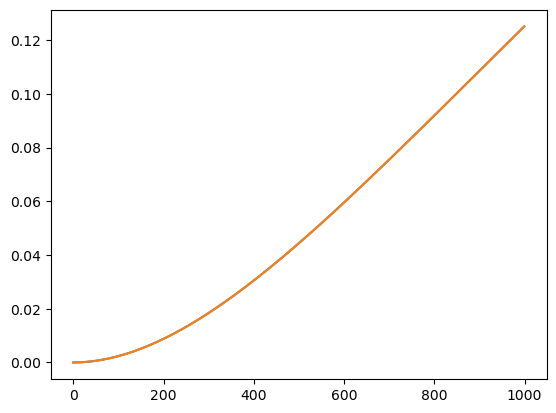

In [35]:
# 2.17
def generate_r(n):
    d = np.ones(n)
    d[0] = 2
    return np.diag(d) + np.diag(np.ones(n-1) * -2, 1) + np.diag(np.ones(n-2), 2)




def generate_a(n):
    d = np.ones(n) * 6
    d[0], d[-2], d[-1] = 9, 5, 1

    d1 = np.ones(n-1) * -4
    d1[-1] = -2

    return np.diag(d) + np.diag(d1, 1) + np.diag(d1, -1) + np.diag(np.ones(n-2), 2) + np.diag(np.ones(n-2), -2)

R = generate_r(10)

# np.allclose(A, R @ R.T)


n = 100
A = generate_a(n)
b = np.ones(n) / n ** 4
x1 = la.solve(A, b)

ab = full_to_banded(A, 2, 2)
x2 = la.solve_banded((2, 2), ab, b)

x1.shape
la.norm(x1 - x2)


from matplotlib import pyplot as plt
n = 1000
A = generate_a(n)
b = np.ones(n) / n ** 4
x1 = la.solve(A, b)

ab = full_to_banded(A, 2, 2)
x2 = la.solve_banded((2, 2), ab, b)

x1.shape
la.norm(x1 - x2)
plt.plot(x1)

R = generate_r(n)
y = la.solve_triangular(R, b)
x3 = la.solve_triangular(R.T, y, lower=True)
plt.plot(x3)
la.norm(x1 - x3, ord=np.inf)

# np.linalg.cond(A)
# np.linalg.cond(R)

# print(la.norm(b - A @ x1))

# print(la.norm(b - A @ x3))
